In [20]:
#imports
import math
import jax
import jax.numpy as jnp
from jax.experimental.ode import odeint
import numpy as np
from functools import partial
import matplotlib.pyplot as plt
from jax.example_libraries import stax
from jax.example_libraries import optimizers
import random as rd
import pickle
import os

In [21]:
#METODA AUTOGRAD

#Definicja Lagrangianu dla podwójnego lagrangianu liczonego w sposób analityczny
#Argumenty funkcji:
#  -q   - położenie ciała
#  -q_t - prędkość ciała
#  -m1  - masa pierwszej kuli
#  -m2  - masa drugiej kuli
#  -l1  - długość pierwszej lini
#  -l2  - długość drugiej lini
#  -g   - wartość przyśpieszenia ziemskiego
#Zwracane: wartość Lagrangianu w danym momencie.
def lagrangian_analitical(q, q_t, m1, m2, l1, l2, g):
        
    # Energia kinetyczna pierwszej kuli
    Ek1 = 0.5*m1*(l1*q_t[0])**2
    # Energia kinetyczna drugiej kuli
    Ek2 = 0.5*m2*((l1*q_t[0])**2 + (l2*q_t[1])**2 + 2*l1*l2*q_t[0]*q_t[1]*jnp.cos(q[0]-q[1]))

    # Energia potencjalna obu kul
    Ep = m1*g*(-1)*l1*jnp.cos(q[0]) + m2*g*(-l1*jnp.cos(q[0]) - l2*jnp.cos(q[1]))

    return Ek1 + Ek2 - Ep

#Obliczenie energi potencjalnej i kinetycznej układu na podstawie aktualnego stanu
#Argumenty funkcji:
#  -q   - położenie ciała
#  -q_t - prędkość ciała
#  -m1  - masa pierwszej kuli
#  -m2  - masa drugiej kuli
#  -l1  - długość pierwszej lini
#  -l2  - długość drugiej lini
#  -g   - wartość przyśpieszenia ziemskiego
#Zwracane: 
#  -Ek  - Energia kinetyczna
#  -Ep  - Energia potencjalna
def compute_energy(q, q_t, m1, m2, l1, l2, g):
    # Energia kinetyczna pierwszej kuli
    Ek1 = 0.5*m1*(l1*q_t[0])**2
    # Energia kinetyczna drugiej kuli
    Ek2 = 0.5*m2*((l1*q_t[0])**2 + (l2*q_t[1])**2 + 2*l1*l2*q_t[0]*q_t[1]*jnp.cos(q[0]-q[1]))

    # Energia potencjalna obu kul
    Ep = m1*g*(-1)*l1*jnp.cos(q[0]) + m2*g*(-l1*jnp.cos(q[0]) - l2*jnp.cos(q[1]))
  

    return Ek1 + Ek2,  Ep

#Funkcja siły działającej na wahadło
def Force(t):
    return jnp.array([0, 0])

#Funkcja ma za zadanie reprezenotwanie równania różniczkowego, wynikającego z rozwiązania
#równanie Eulera-Lagrange'a
#Argumenty funkcji:
#   -lagrangian - Funkcja opisująca Lagrangian. Funkcja musi być typu ,,callable'' żeby,
#                 pochodne Lagrangianu zostały policzone.
#   -state      - Wektor zawierający wartości początkowe położenia i prędkości
#   -empty      - Aby ta funkcja mogła zostać poprawnie wywoływana w dalszej części programu
#                 koniecznym było dodanie ,,pustego'' argumentu, które nie będzie pełnił żadnej
#                 funkcji, ale pozwoli na poprawną kompilację
#Zwracane: Wektor zawiercający przyśpieszenia oraz prędkości w danym momencie.
def equation_of_motion(lagrangian, state, time=None):
    #Rozdzilenie danych startowych na położenia i prędkości
    q, q_t = jnp.split(state, 2)
    q = q.flatten()  
    q_t = q_t.flatten()
    #Obliczanie przyśpieszenia na podstawie lagrangianu
    q_tt = jax.numpy.linalg.pinv(jax.hessian(lagrangian, 1)(q, q_t)) @ (
		jax.grad(lagrangian, 0)(q, q_t)
		- jax.jacfwd(jax.grad(lagrangian, 1), 0)(q, q_t) @ q_t)
    q_tt = q_tt + Force(time)
    return jnp.concatenate([q_t, q_tt])

#Funkcja wyznaczająca trajektorię ruchu przy użyciu Lagrangianu wyznaczonego
#w sposób analityczny
#Argumenty funkcji:
#   -initial_state - Początkowego położenie oraz prędkości
#   -times         - Czas wyznaczanej trajektori
#   -m1  - masa pierwszej kuli
#   -m2  - masa drugiej kuli
#   -l1  - długość pierwszej lini
#   -l2  - długość drugiej lini
#   -g   - wartość przyśpieszenia ziemskiego
#Zwraca:
#   Wektor trajektori ruchu w zależności od czasu
@partial(jax.jit, backend='cpu')
def solve_autograd(initial_state, times, m1=1, m2=1, l1=1, l2=1, g=9.8):
    lagrangian = partial(lagrangian_analitical, m1=m1, m2=m2, l1=l1, l2=l2, g=g)
    equation = partial(equation_of_motion, lagrangian)
    return odeint(equation, initial_state, times, rtol=1e-10, atol=1e-10)


In [22]:
#Funkcja obliczająca przyśpieszenie podwójnego wahadła na podstawie aktualnego położenia i prędkości.
#Argumenty funkcji:
#   -state - Początkowego położenie oraz prędkości
#   -times - Aby ta funkcja mogła zostać poprawnie wywoływana w dalszej części programu
#            koniecznym było dodanie ,,pustego'' argumentu, które nie będzie pełnił żadnej
#            funkcji, ale pozwoli na poprawną kompilację
#   -m1  - masa pierwszej kuli
#   -m2  - masa drugiej kuli
#   -l1  - długość pierwszej lini
#   -l2  - długość drugiej lini
#   -g   - wartość przyśpieszenia ziemskiego
#Zwraca:
#   Wektor trajektori ruchu w zależności od czasu
def analitical(state, time=None ,m1=1, m2=1, l1=1, l2=1, g=9.8):
    q, q_t = jnp.split(state, 2)
    
    a1 = (l2/l1)*(m2/(m1 + m2))*jnp.cos(q[0] - q[1])
    a2 = (l1/l2)*jnp.cos(q[0]-q[1])
    f1 = -(l2/l1)*(m2/(m1 + m2))*(q_t[1]**2)*jnp.sin(q[0] - q[1]) - (g/l1)*jnp.sin(q[0])
    f2 = (l1/l2)*(q_t[0]**2)*jnp.sin(q[0]-q[1]) - (g/l2) * jnp.sin(q[1])
    q_tt_1 = (f1 - a1 * f2) / (1 - a1 * a2)
    q_tt_2 = (f2 - a2 * f1) / (1 - a1 * a2)
    q_tt =  jnp.stack([q_tt_1, q_tt_2])
    
    return jnp.concatenate((jnp.expand_dims(q_t, axis=0), jnp.expand_dims(q_tt, axis=0)), axis=0)

#Funkcja wyznaczająca trajektorię ruchu obliczoną przy użyciu analitycznie wyznaczonego 
# równiania różniczkowego (funkcja analitical)
#Argumenty funkcji:
#   -initial_state - Początkowego położenie oraz prędkości
#   -times         - Czas wyznaczanej trajektori
#   -m1  - masa pierwszej kuli
#   -m2  - masa drugiej kuli
#   -l1  - długość pierwszej lini
#   -l2  - długość drugiej lini
#   -g   - wartość przyśpieszenia ziemskiego
#Zwraca:
#   Wektor trajektori ruchu w zależności od czasu
@partial(jax.jit, backend='cpu')
def solve_analitical(initial_state, times, m1=1, m2=1, l1=1, l2=1, g=9.8):
    function = partial(analitical,m1=m1, m2=m2, l1=l1, l2=l2, g=g)
    return odeint(function, initial_state, t=times, rtol=1e-10, atol=1e-10)


In [23]:
#Punkt startowy
x0 = jnp.array([0,np.pi/2+np.pi,0,0], dtype=np.float32)
#Szum
noise = np.random.RandomState(0).randn(x0.size)
#Wektor czasów
t = np.linspace(0, 40, num=401, dtype=np.float32)

In [24]:
#Funkcja normalizująca kąt Wahadła theta do zakresu <0,2Pi>
def normalize(state):
    theta1 = state[0]  % (2 * np.pi)
    theta2 = state[1]  % (2 * np.pi)
    return jnp.array([theta1, theta2, state[2], state[3]], dtype=np.float32)

In [25]:
#WYZNACZENIE TRAJEKTORI METODĄ AUTOGRAD ORAZ ANALITYCZNĄ

#Autograd
%time autograd_clean = jax.device_get(solve_autograd(x0, t))
autograd_clean = jax.vmap(normalize)(autograd_clean)

#Autograd z małym szumem
%time autograd_noise1 = jax.device_get(solve_autograd(x0 + 1e-10*noise, t))
autograd_noise1 = jax.vmap(normalize)(autograd_noise1)

#Autograd z dużym szumem
%time autograd_noise2 = jax.device_get(solve_autograd(x0 + 1e-5*noise, t))
autograd_noise2 = jax.vmap(normalize)(autograd_noise2)

#Analitycznie 
%time analitical_clean = jax.device_get(solve_analitical(x0, t))
analitical_clean = jax.vmap(normalize)(analitical_clean)
#Analitycznie z małym szumem
%time analitical_noise1 = jax.device_get(solve_analitical(x0 + 1e-10*noise, t))
analitical_noise1 = jax.vmap(normalize)(analitical_noise1)
#Analitycznie z dużym szumem
%time analitical_noise2 = jax.device_get(solve_analitical(x0 + 1e-5*noise, t))
analitical_noise2 = jax.vmap(normalize)(analitical_noise2)

CPU times: user 1.54 s, sys: 634 µs, total: 1.54 s
Wall time: 1.53 s
CPU times: user 242 ms, sys: 172 µs, total: 242 ms
Wall time: 242 ms
CPU times: user 296 ms, sys: 0 ns, total: 296 ms
Wall time: 295 ms
CPU times: user 589 ms, sys: 9.48 ms, total: 598 ms
Wall time: 592 ms
CPU times: user 12.2 ms, sys: 0 ns, total: 12.2 ms
Wall time: 12.2 ms
CPU times: user 14.1 ms, sys: 0 ns, total: 14.1 ms
Wall time: 14.1 ms


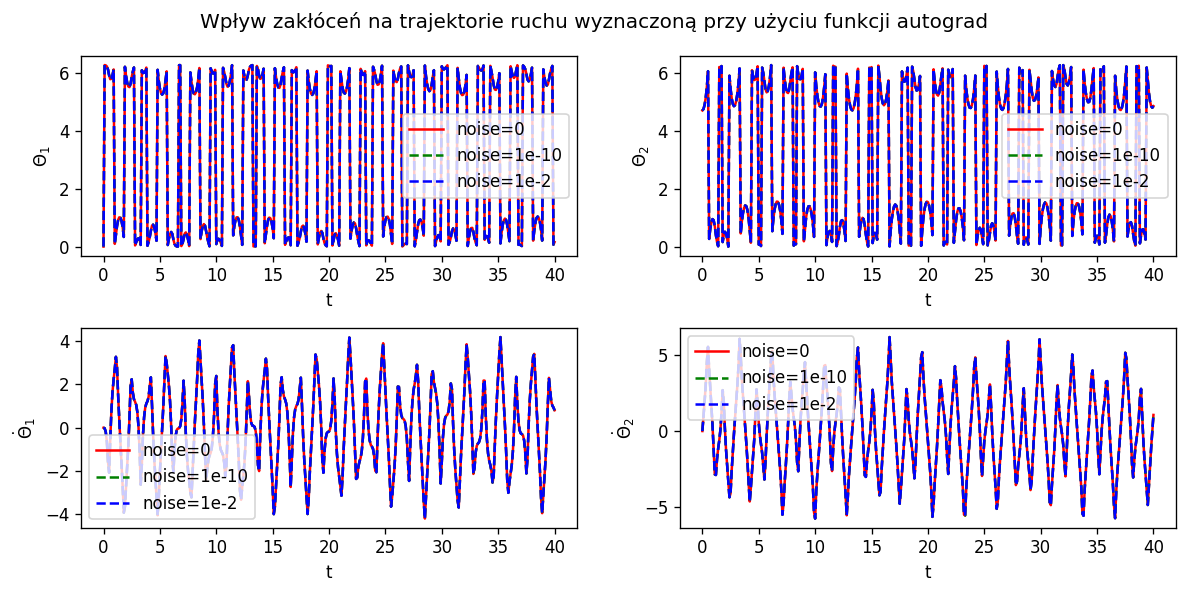

In [26]:
#WYŚWIETLENIE TRAJEKTORI (AUTOGRAD)

fig, axes = plt.subplots(2, 2, figsize=(10, 5), dpi=120)

fig.suptitle("Wpływ zakłóceń na trajektorie ruchu wyznaczoną przy użyciu funkcji autograd")

#Kąt pierwszego wahadła
axes[0,0].plot(t, autograd_clean[:, 0], 'r', label='noise=0')
axes[0,0].plot(t, autograd_noise1[:, 0], 'g--', label='noise=1e-10')
axes[0,0].plot(t, autograd_noise2[:, 0], 'b--', label='noise=1e-2')
axes[0,0].set_xlabel('t')
axes[0,0].set_ylabel('$\Theta_1$')
axes[0,0].legend()
axes[0,1].grid()

#Kąt drugiego wahadła
axes[0,1].plot(t, autograd_clean[:, 1], 'r', label='noise=0')
axes[0,1].plot(t, autograd_noise1[:, 1], 'g--', label='noise=1e-10')
axes[0,1].plot(t, autograd_noise2[:, 1], 'b--', label='noise=1e-2')
axes[0,1].set_xlabel('t')
axes[0,1].set_ylabel('$\Theta_2$')
axes[0,1].legend()
axes[0,1].grid()

#Prędkość kątowa pierwszego wahadła
axes[1,0].plot(t, autograd_clean[:, 2], 'r', label='noise=0')
axes[1,0].plot(t, autograd_noise1[:, 2], 'g--', label='noise=1e-10')
axes[1,0].plot(t, autograd_noise2[:, 2], 'b--', label='noise=1e-2')
axes[1,0].set_xlabel('t')
axes[1,0].set_ylabel('$\dot \Theta_1$')
axes[1,0].legend()
axes[1,1].grid()

#Prędkość prędkość kątowa drugiego wahadła
axes[1,1].plot(t, autograd_clean[:, 3], 'r', label='noise=0')
axes[1,1].plot(t, autograd_noise1[:, 3], 'g--', label='noise=1e-10')
axes[1,1].plot(t, autograd_noise2[:, 3], 'b--', label='noise=1e-2')
axes[1,1].set_xlabel('t')
axes[1,1].set_ylabel('$\dot \Theta_2$')
axes[1,1].legend()
axes[1,1].grid()

plt.tight_layout()

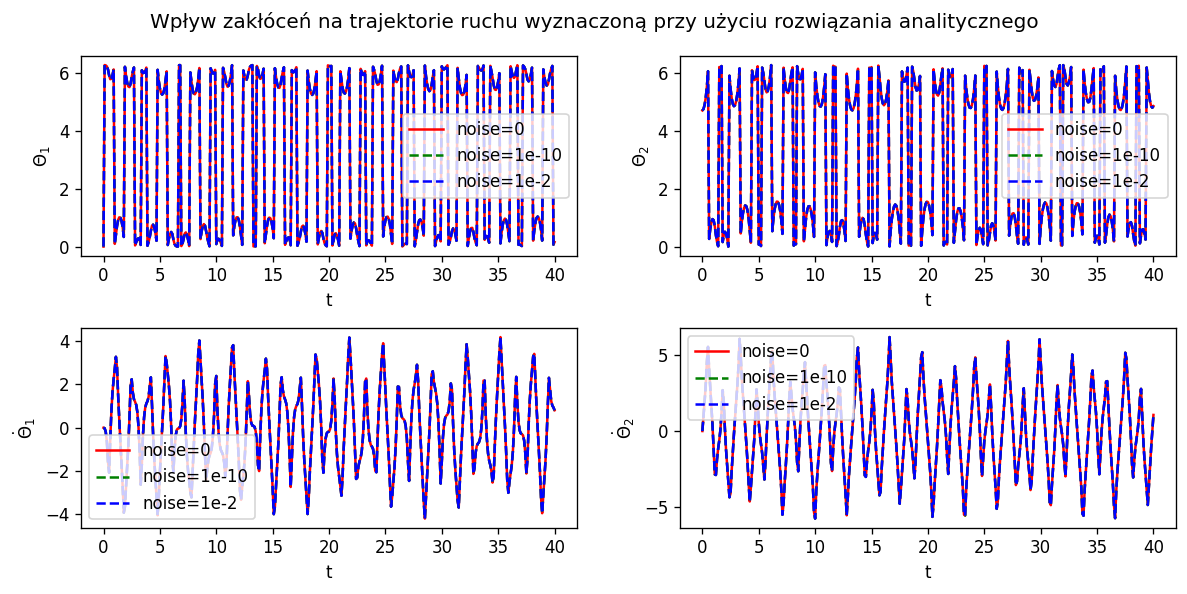

In [27]:
#WYŚWIETLENIE TRAJEKTORI (METODA ANALITYCZNA)

fig, axes = plt.subplots(2, 2, figsize=(10, 5), dpi=120)

fig.suptitle("Wpływ zakłóceń na trajektorie ruchu wyznaczoną przy użyciu rozwiązania analitycznego")

#Kąt pierwszego wahadła
axes[0,0].plot(t, analitical_clean[:, 0], 'r', label='noise=0')
axes[0,0].plot(t, analitical_noise1[:, 0], 'g--', label='noise=1e-10')
axes[0,0].plot(t, analitical_noise2[:, 0], 'b--', label='noise=1e-2')
axes[0,0].set_xlabel('t')
axes[0,0].set_ylabel('$\Theta_1$')
axes[0,0].legend()
axes[0,1].grid()

#Kąt drugiego wahadła
axes[0,1].plot(t, analitical_clean[:, 1], 'r', label='noise=0')
axes[0,1].plot(t, analitical_noise1[:, 1], 'g--', label='noise=1e-10')
axes[0,1].plot(t, analitical_noise2[:, 1], 'b--', label='noise=1e-2')
axes[0,1].set_xlabel('t')
axes[0,1].set_ylabel('$\Theta_2$')
axes[0,1].legend()
axes[0,1].grid()

#Prędkość kątowa pierwszwego wahadła
axes[1,0].plot(t, analitical_clean[:, 2], 'r', label='noise=0')
axes[1,0].plot(t, analitical_noise1[:, 2], 'g--', label='noise=1e-10')
axes[1,0].plot(t, analitical_noise2[:, 2], 'b--', label='noise=1e-2')
axes[1,0].set_xlabel('t')
axes[1,0].set_ylabel('$\dot \Theta_1$')
axes[1,0].legend()
axes[1,1].grid()

#Prędkość kątowa drugiego wahadła
axes[1,1].plot(t, analitical_clean[:, 3], 'r', label='noise=0')
axes[1,1].plot(t, analitical_noise1[:, 3], 'g--', label='noise=1e-10')
axes[1,1].plot(t, analitical_noise2[:, 3], 'b--', label='noise=1e-2')
axes[1,1].set_xlabel('t')
axes[1,1].set_ylabel('$\dot \Theta_2$')
axes[1,1].legend()
axes[1,1].grid()

plt.tight_layout()

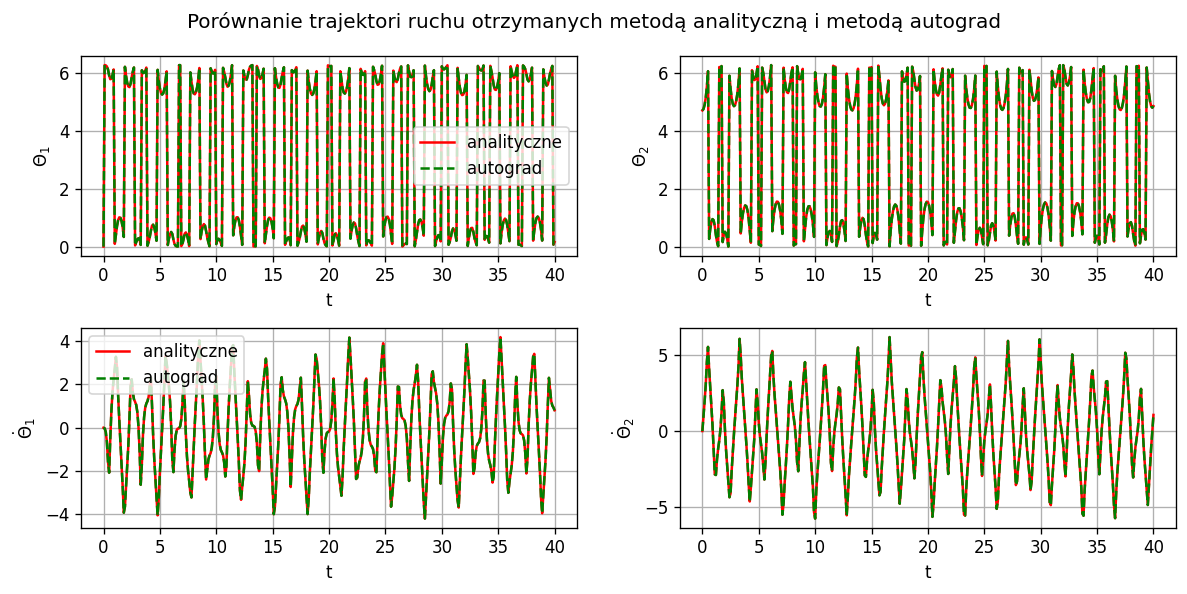

In [28]:
#PORÓWNANIE TRAJEKTORI OTRZYMANYCH PRZY UŻYCIU OBU METOD

fig, axes = plt.subplots(2, 2, figsize=(10, 5), dpi=120)
fig.suptitle('Porównanie trajektori ruchu otrzymanych metodą analityczną i metodą autograd')


#Kąt pierwszwego wahadła
axes[0,0].plot(t, analitical_clean[:, 0], 'r', label='analityczne')
axes[0,0].plot(t, autograd_clean[:, 0], 'g--', label='autograd')
axes[0,0].set_xlabel('t')
axes[0,0].set_ylabel('$\Theta_1$')
axes[0,0].legend()
axes[0,0].grid()

#Kąt drugiego wahadła
axes[0,1].plot(t, analitical_clean[:, 1], 'r', label='analityczne')
axes[0,1].plot(t, autograd_clean[:, 1], 'g--', label='autograd')
axes[0,1].set_xlabel('t')
axes[0,1].set_ylabel('$\Theta_2$')
axes[0,1].grid()

#Prędkość kątowa pierwszego wahadała
axes[1,0].plot(t, analitical_clean[:, 2], 'r', label='analityczne')
axes[1,0].plot(t, autograd_clean[:, 2], 'g--', label='autograd')
axes[1,0].set_xlabel('t')
axes[1,0].set_ylabel('$\dot \Theta_1$')
axes[1,0].legend()
axes[1,0].grid()

#Prędkość kątowa drugiego wahadła
axes[1,1].plot(t, analitical_clean[:, 3], 'r', label='analityczne')
axes[1,1].plot(t, autograd_clean[:, 3], 'g--', label='autograd')
axes[1,1].set_xlabel('t')
axes[1,1].set_ylabel('$\dot \Theta_2$')
axes[1,1].grid()


plt.tight_layout()

[[ 1.9001765   3.2024016   0.17105201  0.07238089]
 [ 0.94062805 -2.4117074   0.27178967 -0.9616746 ]
 [ 0.67645633 -1.4755185   0.01082663 -0.36683956]
 [ 0.96684855  2.2480981  -0.25371164 -0.76057667]
 [-2.173444    1.66687    -0.03302842 -0.6271159 ]
 [-2.2376654  -2.9884253   0.287565   -0.21664982]
 [-3.0265217  -1.4623177  -0.2452815   0.7614075 ]
 [ 2.2441113   0.34048578  0.40889934 -0.5904071 ]
 [-1.9186373  -1.8492515  -0.7828013  -0.25593936]
 [ 0.6243705  -0.3856501   0.2714631   0.8787326 ]
 [ 2.282325   -2.1978273   0.42602032  0.18372822]
 [-1.0390055   0.9059466   0.6787651  -0.658786  ]
 [ 0.72288936  2.4730515   0.50307876 -0.66439325]
 [ 0.24496639 -0.5079201   0.30739188  0.21351567]
 [ 2.970267   -1.8616388  -0.6222746   0.6435084 ]
 [ 1.8811808   0.5332877  -0.62951463  0.12567031]
 [-0.1921635  -1.1360036  -0.37985846 -0.51055515]
 [ 1.448933    1.6214954  -0.7600227  -0.65411025]
 [ 0.8484716   1.0399146  -0.09666161  0.2146327 ]
 [-2.3791375  -3.2357616   0.24

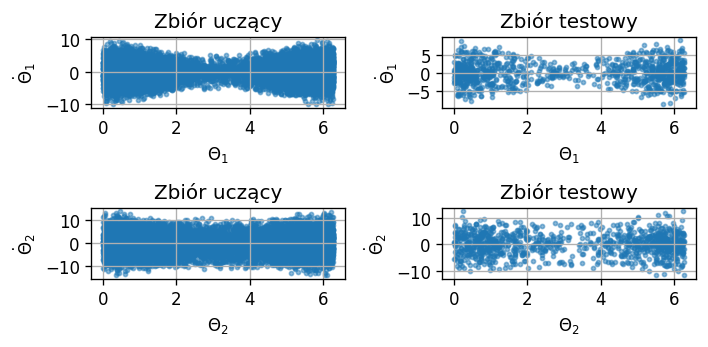

In [29]:
#Budowa zbioru uczącego i testowego
N = 100             #liczba próbek pobieranych z jednej trajektorii
time_step = 0.2     #okres próbkowania
Num_X0_train = 100  #liczba trajektorii dla zbioru uczącego
Num_X0_test = 10    #liczba trajektorii dla zbioru testowego

x0_train = np.zeros([Num_X0_train, 4],  dtype=jnp.float32)
x0_test = np.zeros([Num_X0_test, 4],  dtype=jnp.float32)

#ZAKRESY
#Theta1 = <-Pi,Pi>
#Theta2 = <-Pi, Pi>
#Theta'1 = <-1, 1>
#Theta'2 = <-1, 1>

eps = 0.1

#Punkty startowe dla trajektorii dla zbioru uczącego
x0_train[:,0] = np.random.rand(Num_X0_train)*2*(np.pi + eps) - (np.pi + eps)
x0_train[:,1] = np.random.rand(Num_X0_train)*2*(np.pi + eps) - (np.pi + eps)
x0_train[:,2] = np.random.rand(Num_X0_train)*2*1 - 1
x0_train[:,3] = np.random.rand(Num_X0_train)*2*1 - 1

#Punkty startowe dla trajektorii dla zbioru testowego
x0_test[:,0] = np.random.rand(Num_X0_test)*2*(np.pi + eps) - (np.pi + eps)
x0_test[:,1] = np.random.rand(Num_X0_test)*2*(np.pi + eps) - (np.pi + eps)
x0_test[:,2] = np.random.rand(Num_X0_test)*2*1 - 1
x0_test[:,3] = np.random.rand(Num_X0_test)*2*1 - 1

print(x0_train)
print(x0_test)
t = jnp.linspace(0, N * time_step, num=N, dtype=jnp.float32)

x_train = jnp.zeros([x0_train.shape[0]*N, 4])
y_train = jnp.zeros([x0_train.shape[0]*N, 4])
x_test = jnp.zeros([x0_test.shape[0]*N, 4])
y_test = jnp.zeros([x0_test.shape[0]*N, 4])

fig, axes = plt.subplots(2, 2, figsize=(6, 3), dpi=120)


#Budowa zbioru uczącego
for i in range(x0_train.shape[0]):
    trajectory = jax.device_get(solve_analitical(x0_train[i], t))
    trajectory = jax.vmap(normalize)(trajectory)
    x_train = x_train.at[i * N:(i + 1)*N, 0:4].set(trajectory)
    

    accelerations = jax.vmap(analitical)(trajectory)
    accelerations = jax.device_get(accelerations)
    y_train = y_train.at[i * N:(i + 1)*N, 0:2].set(accelerations[:,0,:])
    y_train = y_train.at[i * N:(i + 1)*N, 2:4].set(accelerations[:,1,:])

axes[0,0].scatter(x_train[:, 0], x_train[:, 2], s=6, alpha=0.5)
axes[1,0].scatter(x_train[:, 1], x_train[:, 3], s=6, alpha=0.5)

#Budowa zbioru testowego
for i in range(x0_test.shape[0]):
    trajectory = jax.device_get(solve_analitical(x0_test[i], t))
    trajectory = jax.vmap(normalize)(trajectory)
    x_test = x_test.at[i * N:(i + 1) * N, 0:4].set(trajectory)

    accelerations = jax.vmap(analitical)(trajectory)
    accelerations = jax.device_get(accelerations)
    y_test = y_test.at[i * N:(i + 1) * N, 0:2].set(accelerations[:,0,:])
    y_test = y_test.at[i * N:(i + 1) * N, 2:4].set(accelerations[:,1,:])


#Wizualizacja zbioru
axes[0,1].scatter(x_test[:, 0], x_test[:, 2], s=6, alpha=0.5)
axes[1,1].scatter(x_test[:, 1], x_test[:, 3], s=6, alpha=0.5)

axes[0,0].set_xlabel('$\Theta_1$')
axes[0,0].set_ylabel('$\dot \Theta_1$')
axes[0,0].set_title('Zbiór uczący')
axes[0,0].grid()

axes[1,0].set_xlabel('$\Theta_2$')
axes[1,0].set_ylabel('$\dot \Theta_2$')
axes[1,0].set_title('Zbiór uczący')
axes[1,0].grid()

axes[0,1].set_xlabel('$\Theta_1$')
axes[0,1].set_ylabel('$\dot \Theta_1$')
axes[0,1].set_title('Zbiór testowy')
axes[0,1].grid()

axes[1,1].set_xlabel('$\Theta_2$')
axes[1,1].set_ylabel('$\dot \Theta_2$')
axes[1,1].set_title('Zbiór testowy')
axes[1,1].grid()

plt.tight_layout()

In [30]:
#ARCHITEKUTRA SIECI NEURONOWEJ
layers=[4,32,32,32,1]
init_random_params, nn_forward_fn = stax.serial(
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(1),
)

#Funkcja inicjalizująca wagi sieci metodą He
#Argumenty funkcji:
#   sizes - Wektor rozmiarów warsztw sieci [wejściowa, ukryte, wyjściowa]
#   key   - ziarno dla generatora liczb losowych
#Zwraca:
#   params - macierz wag i biasów
def he_init_network_params(sizes, key):
    keys = jax.random.split(key, len(sizes) - 1)  
    params = []
    
    for m, n, k in zip(sizes[:-1], sizes[1:], keys):
        weight_key, bias_key = jax.random.split(k) 
        
        # Inicjalizacja wag metodą He
        weights = jax.nn.initializers.he_normal()(weight_key, (m, n))
        # Inicjalizacja biasów
        biases = jnp.ones((n,))
        
        params.append((weights, biases))
    
    return params


#Funkcja modelująca lagrangian (wyjście sieci neuronowej)
#Argumenty:
#   params - parametry sieci neuronowej
#   q, q_t - wektor wartości wejściowych dla sieci (położenie, przyśpieszenie)
#Zwraca:
#   lagrangian - wartość lagrangianu dla danego wektora stanu
def learned_lagrangian(params):
    def lagrangian(q, q_t):
      assert q.shape == (2,)
      state = jnp.concatenate([q, q_t])
      return jnp.squeeze(nn_forward_fn(params, state), axis=-1)
    return lagrangian

#Funkcja wyznaczająca trajektorię ruchu przy użyciu Lagrangianu zamodlowanego za pomocą sieci neuronowej
#Argumenty funkcji:
#   -params        - Parametry sieci neuronowej
#   -initial_state - Początkowego położenie oraz prędkości
#   -times         - Czas wyznaczanej trajektori
#Zwraca:
#   Wektor trajektori ruchu w zależności od czasu
@partial(jax.jit, backend='cpu')
def solve_lagrangian(params, initial_state, times):
  return odeint(partial(equation_of_motion, learned_lagrangian(params)),
                  initial_state, times, rtol=1e-10, atol=1e-10)
  
  
#Funkcja ma za zadanie obliczenie przyśpieszenia na podstawie aktualnego stanu
#(położenie i przyśpieszenie) przy użyciu lagrangianu zamodelowanego przez sieć LNN.
#Argumenty funkcji:
#   -params     - Parametry sieci.
#   -state      - Wektor zawierający wartości początkowe położenia i prędkości [q, q_t].
#Zwracane:  Przyśpieszenie wynikającego z aktulanego wektora stanu.  
def acceleration_learned(params, initial_state):
  acc = partial(equation_of_motion, learned_lagrangian(params))
  return acc(initial_state)[2:4]


#DEFINICJA BŁĘDU DLA SIECI
#Argumenty:
#   params  - parametry sieci neuronowej
#   state   - wektor stanu [położenie, prędkość]
#   target  - oczekiwany wektor wyjściowy sieci [prędkość, przyśpieszenie]
@partial(jax.jit, backend='cpu')
def MSE_loss(params, state, targets):
  preds = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(state)
  return jnp.mean((preds- targets) ** 2)


#Funkcja zamieniająca losowe elementy 2 wektorów w ten sam sposób.
#Argumenty:
#   a, b - Wektory, które mają zostać przemieszane.
#Zawracane:
#   a, b - Przetasowane wektory.
def shuffle(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(a.shape[0])
    return a[p], b[p]

In [31]:
%%time
#UCZENIE SIECI NEURONOWEJ





Training=True    #Uczenie sieci
Epochs=1000       #Maksymalna liczba epok
StopError=0.001      #Wartość błędu MSE dla zbioru testowego, przy której uczenie zostanie szybciej zakończone
Learning_rate=1e-3  #Współczynnik uczenia
Batch_size= 64


train_error=[]      #Wektor błędów MSE dla zbioru uczącego
test_error=[]       ##Wektor błędów MSE dla zbioru testowego


#Ścieżka dla pliku przechowującego parametry sieci
config = {"ckpt_path": "Checkpoints"}

#Inicjalizacja parametrów sieci
rng = jax.random.PRNGKey(0)
output_shape, params_initial = init_random_params(rng, (-1, 4))

#Wybór optymalizotra sieci ADAM
init, update, get_params = optimizers.adam(step_size=Learning_rate)
update = jax.jit(update)
get_params = jax.jit(get_params)


#Wykonanie uczenia sieci
if(Training):
    
    x_train = jax.device_get(x_train)
    x_test = jax.device_get(x_test)
    y_train = jax.device_get(y_train)
    y_test = jax.device_get(y_test)

    best_error = float('inf')

    opt_state = init(params_initial)
    for i in range(Epochs):
        #Realizacja minibatcha
        x_train, y_train = shuffle(x_train, y_train)
        start=0
        while start < x_train.shape[0]:
            #Podział danych na batche
            end = start+Batch_size
            if end > x_train.shape[0]:
                end = x_train.shape[0]
            x_batch = x_train[start:end, :]
            y_batch = y_train[start:end, :]

            #Obliczenie błędu MSE i optymalizacja wag
            params = get_params(opt_state)
            grad = jax.grad(MSE_loss)(params, x_batch, y_batch)
            opt_state = update(i, grad, opt_state)

            start += Batch_size


        #Zapisanie błędu na podstawie zbioru uczącego i testowego w każdej epoce
        train_error.append(MSE_loss(params, x_train, y_train))
        test_error.append(MSE_loss(params, x_test, y_test))

        #Zapamiętywanie najlepszych parametrów sieci
        if test_error[-1]<best_error:
            best_error = test_error[-1]
            best_params = params


        #Wcześciejsze kończenie uczenia
        if test_error[-1]<=StopError:
            print(f"iteration={i}, train_loss={train_error[-1]:.6f}, test_loss={test_error[-1]:.6f}, best_loss={best_error:.6f}")
            break

        #Wyświetlanie informacji o postępie uczenia
        if i%1==0:
            print(f"iteration={i}, train_loss={train_error[-1]:.6f}, test_loss={test_error[-1]:.6f}, best_loss={best_error:.6f}")
    
    #Wybór najlepszych parametrów
    params = best_params

    #Zapisanie parametrów do pliku
    pickle.dump(params, open(os.path.join(config["ckpt_path"], "PodwojneWahadlo.pkl"), "wb"))

#Brak uczenia - odczyt parametrów z pliku
else:
    params = pickle.load(open(os.path.join(config["ckpt_path"], "PodwojneWahadlo.pkl"), "rb"))
    #opt_state = optimizers.pack_optimizer_state(params)
    
    


iteration=0, train_loss=130.317322, test_loss=124.013519, best_loss=124.013519
iteration=1, train_loss=126.935120, test_loss=120.937431, best_loss=120.937431
iteration=2, train_loss=125.303146, test_loss=119.837006, best_loss=119.837006
iteration=3, train_loss=124.418869, test_loss=119.204849, best_loss=119.204849
iteration=4, train_loss=123.132195, test_loss=118.952942, best_loss=118.952942
iteration=5, train_loss=121.885231, test_loss=118.260468, best_loss=118.260468
iteration=6, train_loss=121.478188, test_loss=120.038643, best_loss=118.260468
iteration=7, train_loss=120.504410, test_loss=116.659691, best_loss=116.659691
iteration=8, train_loss=120.629822, test_loss=120.140915, best_loss=116.659691
iteration=9, train_loss=118.472794, test_loss=116.330444, best_loss=116.330444
iteration=10, train_loss=119.207794, test_loss=115.215004, best_loss=115.215004
iteration=11, train_loss=118.632172, test_loss=116.325150, best_loss=115.215004
iteration=12, train_loss=117.353569, test_loss=115

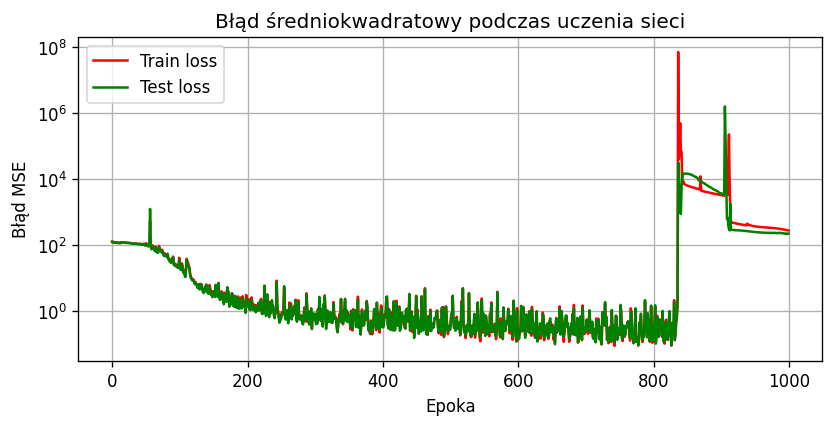

In [32]:
#WIZUALIZACJA BŁĘDU MSE PODCZAS UCZENIA SIECI

plt.figure(figsize=(8, 3.5), dpi=120)
plt.plot(train_error[:], 'r', label='Train loss')
plt.plot(test_error[:], 'g', label='Test loss')
plt.yscale('log')
plt.title('Błąd średniokwadratowy podczas uczenia sieci')
plt.xlabel("Epoka") 
plt.ylabel("Błąd MSE")
plt.grid()
plt.legend()
plt.show()

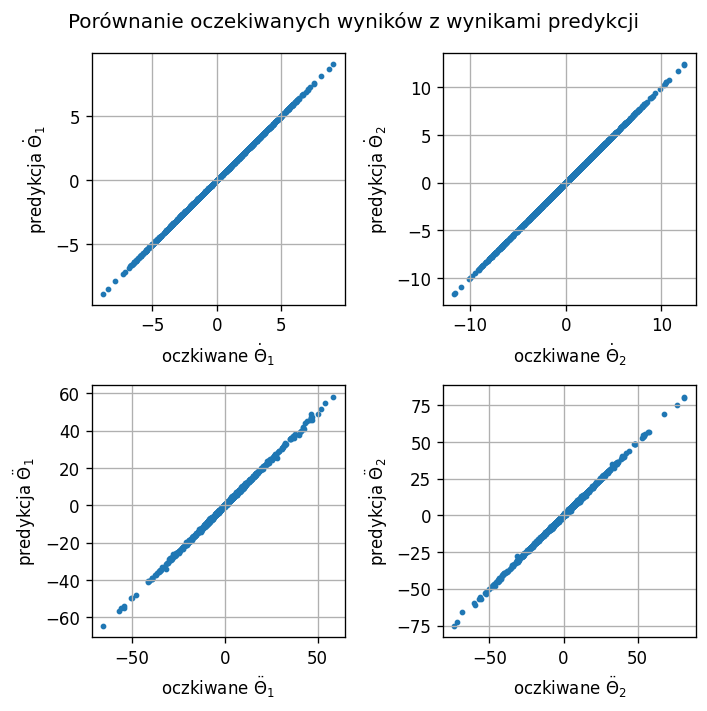

In [33]:
#TEST PREDYKCJI SIECI

#Obliczenie predykcji sieci (wartość wyjściowa) na podstawie zbioru testowego
y_pred = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(x_test)

#Wizualizacji wyników
fig, axes = plt.subplots(2, 2, figsize=(6, 6), dpi=120)
fig.suptitle("Porównanie oczekiwanych wyników z wynikami predykcji")
axes[0,0].scatter(y_test[:, 0], y_pred[:, 0], s=6, alpha=1)
axes[0,0].set_xlabel('oczkiwane $\dot \Theta_1$')
axes[0,0].set_ylabel('predykcja $\dot \Theta_1$')
axes[0,0].grid()
axes[0,1].scatter(y_test[:, 1], y_pred[:, 1], s=6, alpha=1)
axes[0,1].set_xlabel('oczkiwane $\dot \Theta_2$')
axes[0,1].set_ylabel('predykcja $\dot \Theta_2$')
axes[0,1].grid()
axes[1,0].scatter(y_test[:, 2], y_pred[:, 2], s=6, alpha=1)
axes[1,0].set_xlabel('oczkiwane $\ddot \Theta_1$')
axes[1,0].set_ylabel('predykcja $\ddot \Theta_1$')
axes[1,0].grid()
axes[1,1].scatter(y_test[:, 3], y_pred[:, 3], s=6, alpha=1)
axes[1,1].set_xlabel('oczkiwane $\ddot \Theta_2$')
axes[1,1].set_ylabel('predykcja $\ddot \Theta_2$')
axes[1,1].grid()
plt.tight_layout()

In [36]:
#Punkt startowy 

x0 = jnp.array([0,0.1,0,0], dtype=np.float32)
#Szum
noise = np.random.RandomState(0).randn(x0.size)
#Wektor czasów
t = np.linspace(0, 40, num=401, dtype=np.float32)


%time trajectory_autograd = jax.device_get(solve_autograd(x0, t))

%time trajectory_LNN = jax.device_get(solve_lagrangian(params, x0, t))

CPU times: user 60.3 ms, sys: 0 ns, total: 60.3 ms
Wall time: 57.9 ms
CPU times: user 18.5 s, sys: 16.2 ms, total: 18.5 s
Wall time: 18.5 s


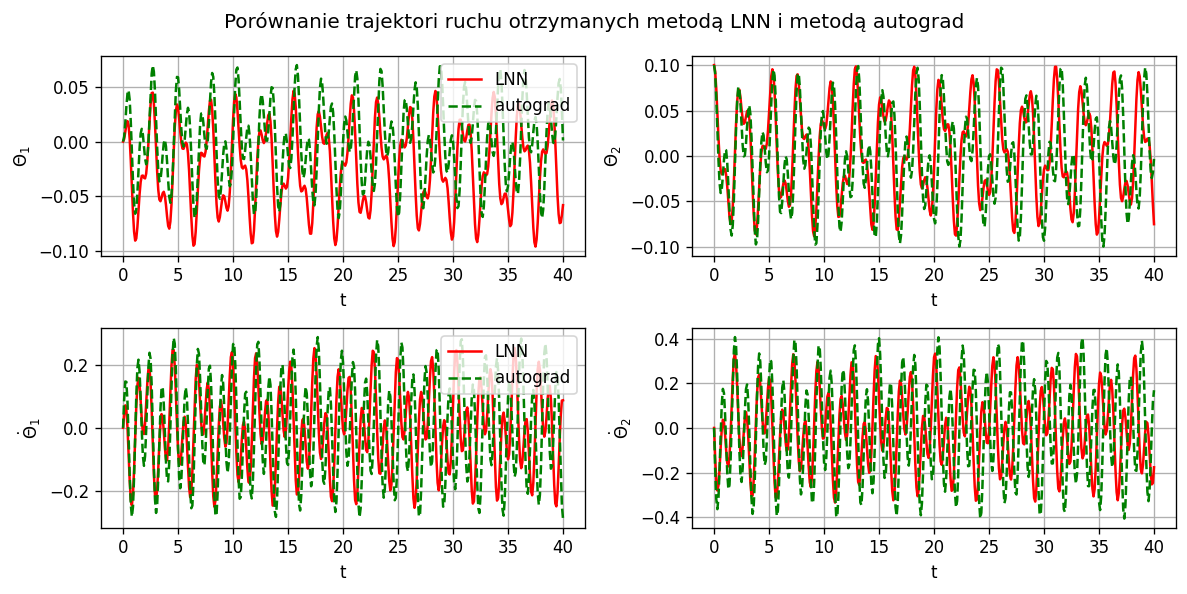

In [37]:
#PORÓWNANIE TRAJEKTORI OTRZYMANYCH PRZY UŻYCIU OBU METOD

fig, axes = plt.subplots(2, 2, figsize=(10, 5), dpi=120)
fig.suptitle('Porównanie trajektori ruchu otrzymanych metodą LNN i metodą autograd')


#Kąt pierwszwego wahadła
axes[0,0].plot(t, trajectory_LNN[:, 0], 'r', label='LNN')
axes[0,0].plot(t, trajectory_autograd[:, 0], 'g--', label='autograd')
axes[0,0].set_xlabel('t')
axes[0,0].set_ylabel('$\Theta_1$')
axes[0,0].legend()
axes[0,0].grid()

#Kąt drugiego wahadła
axes[0,1].plot(t, trajectory_LNN[:, 1], 'r', label='LNN')
axes[0,1].plot(t, trajectory_autograd[:, 1], 'g--', label='autograd')
axes[0,1].set_xlabel('t')
axes[0,1].set_ylabel('$\Theta_2$')
axes[0,1].grid()

#Prędkość kątowa pierwszego wahadała
axes[1,0].plot(t, trajectory_LNN[:, 2], 'r', label='LNN')
axes[1,0].plot(t, trajectory_autograd[:, 2], 'g--', label='autograd')
axes[1,0].set_xlabel('t')
axes[1,0].set_ylabel('$\dot \Theta_1$')
axes[1,0].legend()
axes[1,0].grid()

#Prędkość kątowa drugiego wahadła
axes[1,1].plot(t, trajectory_LNN[:, 3], 'r', label='LNN')
axes[1,1].plot(t, trajectory_autograd[:, 3], 'g--', label='autograd')
axes[1,1].set_xlabel('t')
axes[1,1].set_ylabel('$\dot \Theta_2$')
axes[1,1].grid()


plt.tight_layout()